In [2]:
import os
import time
from PIL import Image

import numpy as np
import pandas as pd

import torch

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn import functional as F
from torchvision import transforms as Transform
from torchinfo import summary    # torchinfo not available on collab, use torchsummary.

from matplotlib import pyplot as plt

In [56]:
DATA_DIR = './data/'
DATA_FOLDER = './data/'
DATA_FILE = 'dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz'
IMAGE_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 128
NUM_FEATURES = 64
EMBEDDING_DIM = 200
LEARNING_RATE = 1e-3
EPOCHS = 15
BETA = 1.2

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

cuda


In [38]:
# load dataset
dataset_zip = np.load(os.path.join(DATA_DIR, DATA_FILE), allow_pickle=True, encoding="bytes")

print(type(dataset_zip))

print("keys in dataset: ", dataset_zip.keys())
imgs = dataset_zip["imgs"]
latents_values = dataset_zip["latents_values"]
latents_classes = dataset_zip["latents_classes"]
metadata = dataset_zip["metadata"][()]  # python indexing into a 0D array

<class 'numpy.lib.npyio.NpzFile'>
keys in dataset:  KeysView(NpzFile './data/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz' with keys: metadata, imgs, latents_classes, latents_values)


c:\Users\NODDL\anaconda3\envs\torchclean1\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [ ]:
latents_classes.shape, imgs.shape

((737280, 6), (737280, 64, 64))

In [48]:
latents_classes, imgs

(array([[ 0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  2],
        ...,
        [ 0,  2,  5, 39, 31, 29],
        [ 0,  2,  5, 39, 31, 30],
        [ 0,  2,  5, 39, 31, 31]], shape=(737280, 6)),
 array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 

In [29]:
metadata.keys()
# latent_sizes: how many values in each latent dimension

dict_keys([b'date', b'description', b'version', b'latents_names', b'latents_possible_values', b'latents_sizes', b'author', b'title'])

In [31]:
# Define number of values per latents and functions to convert to indices
latents_sizes = metadata[b'latents_sizes']  # old stuff stored as python bytes
latents_bases = np.concatenate((latents_sizes[::-1].cumprod()[::-1][1:],
                                np.array([1,])))

def latent_to_index(latents):
  return np.dot(latents, latents_bases).astype(int)


def sample_latent(size=1):
  samples = np.zeros((size, latents_sizes.size))
  for lat_i, lat_size in enumerate(latents_sizes):
    samples[:, lat_i] = np.random.randint(lat_size, size=size)

  return samples

In [53]:

# Helper function to show images
def show_images_grid(imgs_, num_images=25):
  ncols = int(np.ceil(num_images**0.5))
  nrows = int(np.ceil(num_images / ncols))
  _, axes = plt.subplots(ncols, nrows, figsize=(nrows * 3, ncols * 3))
  axes = axes.flatten()

  for ax_i, ax in enumerate(axes):
    if ax_i < num_images:
      ax.imshow(imgs_[ax_i], cmap='Greys_r',  interpolation='nearest')
      ax.set_xticks([])
      ax.set_yticks([])
    else:
      ax.axis('off')

def show_density(imgs):
  _, ax = plt.subplots()
  ax.imshow(imgs.mean(axis=0), interpolation='nearest', cmap='Greys_r')
  ax.grid('off')
  ax.set_xticks([])
  ax.set_yticks([])

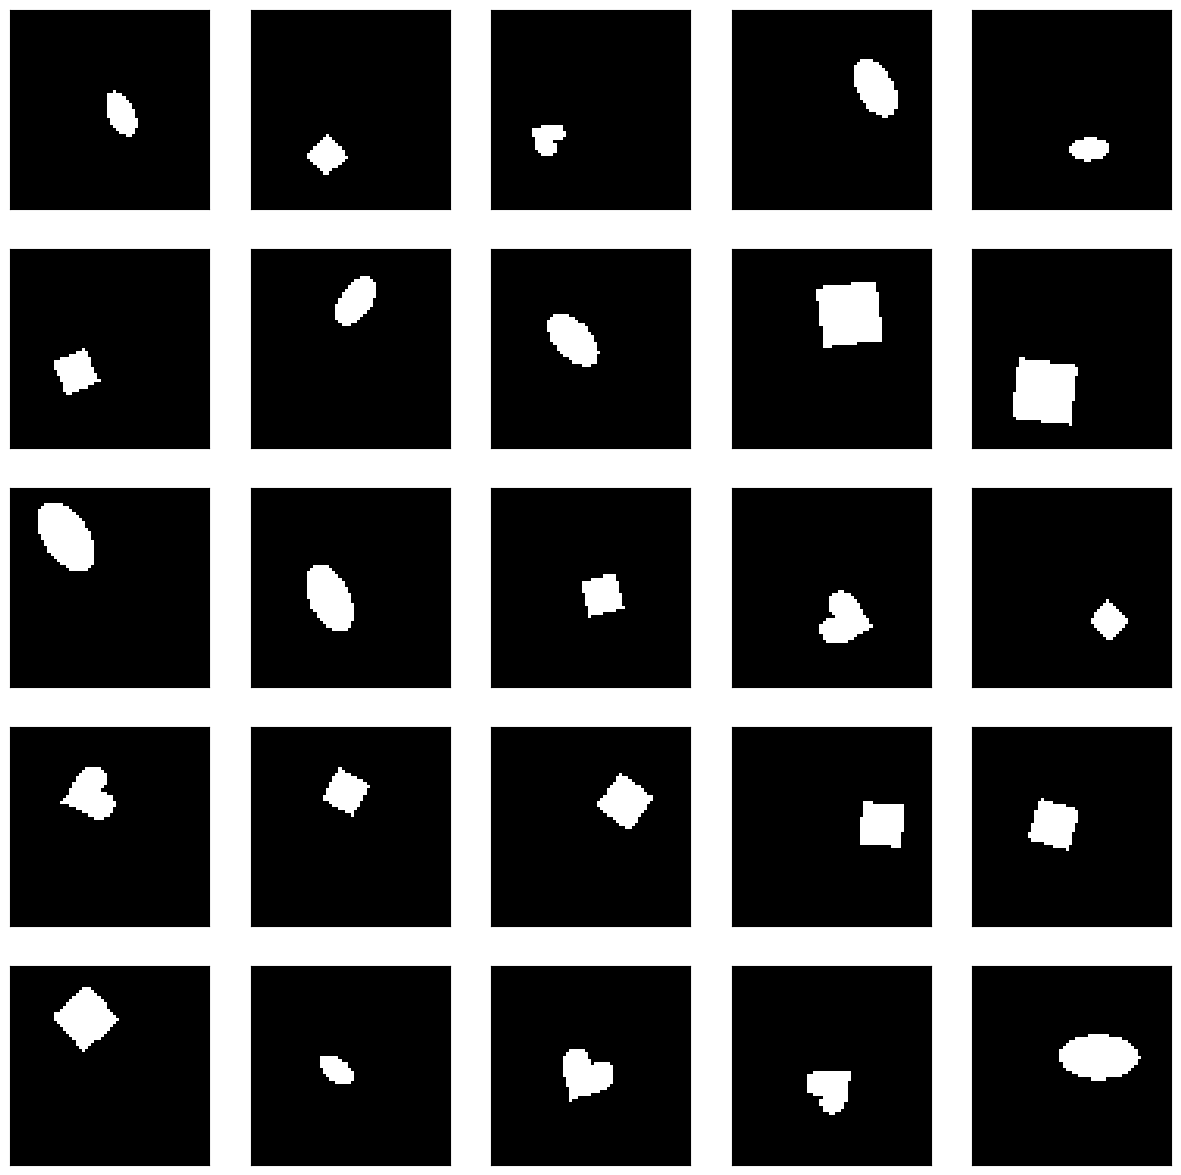

In [54]:
# Sample latents randomly
latents_sampled = sample_latent(size=5000)

# Select images
indices_sampled = latent_to_index(latents_sampled)
imgs_sampled = imgs[indices_sampled]

# Show images
show_images_grid(imgs_sampled)

In [ ]:
# issue, will use up like 13 GB of RAM since dsprites dataset must be completed loaded in/stored in the dataset_zip["imgs"]
# not solution found yet excpet get more RAM (use google collab)

class dSprites(Dataset):
    def __init__(self, data_path):
        self.dataset_zip = np.load(data_path, allow_pickle=True, encoding="bytes")
        self.imgs = dataset_zip["imgs"]
        self.latents_values = dataset_zip["latents_values"]
        self.latents_classes = dataset_zip["latents_classes"]
        self.metadata = dataset_zip["metadata"][()] # python indexing into 0D array

        self.length = imgs.shape[0]
    
    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        return torch.from_numpy(self.imgs[idx])

In [57]:
def get_dataloaders():
    dSprites_ds = dSprites(os.path.join(DATA_DIR, DATA_FILE))
    train_ds, test_ds = random_split(imgs, [0.8, 0.2])
    print('Train data size: {}'.format(len(train_ds)))
    print('Test data size: {}'.format(len(test_ds)))

    train_loader = DataLoader(dataset=train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=8, pin_memory=True)
    test_loader = DataLoader(dataset=test_ds, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=8, pin_memory=True)
    return train_loader, test_loader

In [58]:
train_loader, test_loader = get_dataloaders()

c:\Users\NODDL\anaconda3\envs\torchclean1\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Train data size: 589824
Test data size: 147456


In [ ]:
train_iter = iter(train_loader)
test_iter = iter(test_loader)